# Klasifikasi Experience Level Gym Member Menggunakan Decision Tree

Notebook ini menganalisis data gym member untuk memprediksi **tingkat pengalaman (Experience Level)** anggota gym berdasarkan data aktivitas dan fisik mereka, menggunakan algoritma **Decision Tree Classifier**.

## 1. Problem Statement (Rumusan Masalah)

**Latar Belakang:**
Gym member exercise tracking data mencatat berbagai atribut fisik dan kebiasaan latihan anggota gym. Salah satu label penting dalam data ini adalah `Experience_Level`, yang mengelompokkan anggota ke dalam tingkat pemula (1), menengah (2), dan mahir (3).

**Rumusan Masalah:**
- Faktor apa saja (fisik maupun kebiasaan latihan) yang paling berpengaruh dalam menentukan tingkat pengalaman (Experience Level) seorang gym member?
- Seberapa akurat model Decision Tree dapat mengklasifikasikan Experience Level berdasarkan faktor-faktor tersebut?

**Tujuan Analisis:**
1. Membangun model klasifikasi Experience Level menggunakan Decision Tree.
2. Mengidentifikasi fitur-fitur yang paling berkontribusi terhadap prediksi.
3. Mengevaluasi performa model secara valid.

**Target/Label:** `Experience_Level` (1 = Pemula, 2 = Menengah, 3 = Mahir)

In [ ]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from scipy.stats import zscore

from sklearn.preprocessing import LabelEncoder
from sklearn.model_selection import train_test_split, cross_val_score, GridSearchCV
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.dummy import DummyClassifier
from sklearn.metrics import confusion_matrix, classification_report, accuracy_score
import joblib

pd.set_option('display.max_columns', None)
sns.set_style('whitegrid')

## 2. Data Understanding

Tahap ini bertujuan untuk memahami struktur, kualitas, dan karakteristik awal data sebelum tahap pembersihan.

In [ ]:
df = pd.read_csv('gym_members_exercise_tracking.csv', delimiter=';')
print("Jumlah baris & kolom:", df.shape)
df.head()

Jumlah baris & kolom: (973, 15)


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,Male,88.3,1.71,180,157,60,1.69,1313.0,Yoga,12.6,3.5,4,3,30.20
1,46,Female,74.9,1.53,179,151,66,1.30,883.0,HIIT,33.9,2.1,4,2,32.00
2,32,Female,68.1,1.66,167,122,54,1.11,677.0,Cardio,33.4,2.3,4,2,24.71
3,25,Male,53.2,1.70,190,164,56,0.59,532.0,Strength,28.8,2.1,3,1,18.41
4,38,Male,46.1,1.79,188,158,68,0.64,556.0,Strength,29.2,2.8,3,1,14.39


In [ ]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 973 entries, 0 to 972
Data columns (total 15 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Age                            973 non-null    int64  
 1   Gender                         973 non-null    str    
 2   Weight (kg)                    973 non-null    float64
 3   Height (m)                     973 non-null    float64
 4   Max_BPM                        973 non-null    int64  
 5   Avg_BPM                        973 non-null    int64  
 6   Resting_BPM                    973 non-null    int64  
 7   Session_Duration (hours)       973 non-null    float64
 8   Calories_Burned                973 non-null    float64
 9   Workout_Type                   973 non-null    str    
 10  Fat_Percentage                 973 non-null    float64
 11  Water_Intake (liters)          973 non-null    float64
 12  Workout_Frequency (days/week)  973 non-null    int64  
 13  E

In [ ]:
print("Statistik Deskriptif:")
df.describe(include='all')

Statistik Deskriptif:


,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
count,973.000000,973,973.000000,973.00000,973.000000,973.000000,973.000000,973.000000,973.000000,973,973.000000,973.000000,973.000000,973.000000,973.000000
unique,NaN,2,NaN,NaN,NaN,NaN,NaN,NaN,NaN,4,NaN,NaN,NaN,NaN,NaN
top,NaN,Male,NaN,NaN,NaN,NaN,NaN,NaN,NaN,Strength,NaN,NaN,NaN,NaN,NaN
freq,NaN,511,NaN,NaN,NaN,NaN,NaN,NaN,NaN,258,NaN,NaN,NaN,NaN,NaN
mean,38.683453,NaN,73.854676,1.72258,179.883864,143.766701,62.223022,1.256423,905.422405,NaN,24.976773,2.626619,3.321686,1.809866,24.912127
std,12.180928,NaN,21.207500,0.12772,11.525686,14.345101,7.327060,0.343033,272.641516,NaN,6.259419,0.600172,0.913047,0.739693,6.660879
min,18.000000,NaN,40.000000,1.50000,160.000000,120.000000,50.000000,0.500000,303.000000,NaN,10.000000,1.500000,2.000000,1.000000,12.320000
25%,28.000000,NaN,58.100000,1.62000,170.000000,131.000000,56.000000,1.040000,720.000000,NaN,21.300000,2.200000,3.000000,1.000000,20.110000
50%,40.000000,NaN,70.000000,1.71000,180.000000,143.000000,62.000000,1.260000,893.000000,NaN,26.200000,2.600000,3.000000,2.000000,24.160000
75%,49.000000,NaN,86.000000,1.80000,190.000000,156.000000,68.000000,1.460000,1076.000000,NaN,29.300000,3.100000,4.000000,2.000000,28.560000


In [ ]:
print("Jumlah Missing Value per kolom:")
print(df.isnull().sum())

print("\nJumlah Data Duplikat:", df.duplicated().sum())

Jumlah Missing Value per kolom:
Age                              0
Gender                           0
Weight (kg)                      0
Height (m)                       0
Max_BPM                          0
Avg_BPM                          0
Resting_BPM                      0
Session_Duration (hours)         0
Calories_Burned                  0
Workout_Type                     0
Fat_Percentage                   0
Water_Intake (liters)            0
Workout_Frequency (days/week)    0
Experience_Level                 0
BMI                              0
dtype: int64

Jumlah Data Duplikat: 0


/tmp/ipykernel_552/252078923.py:2: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.countplot(x='Experience_Level', data=df, palette='Set2')


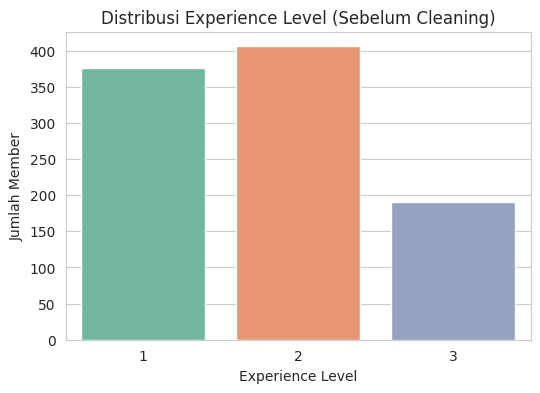

Experience_Level
1    0.386434
2    0.417266
3    0.196300
Name: proportion, dtype: float64


In [ ]:
plt.figure(figsize=(6, 4))
sns.countplot(x='Experience_Level', data=df, palette='Set2')
plt.title('Distribusi Experience Level (Sebelum Cleaning)')
plt.xlabel('Experience Level')
plt.ylabel('Jumlah Member')
plt.show()

print(df['Experience_Level'].value_counts(normalize=True).sort_index())

**Catatan Data Understanding:**
Distribusi target menunjukkan sedikit ketidakseimbangan kelas (kelas 3 / mahir jumlahnya lebih sedikit dibanding kelas 1 dan 2). Hal ini perlu diperhatikan saat evaluasi modeel

## 3. Data Preparation

Tahap pembersihan data: menghapus missing value & duplikat, menghapus outlier menggunakan Z-score, dan encoding fitur kategorikal.

In [ ]:
jumlah_sebelum = len(df)

df = df.dropna()
df = df.drop_duplicates()

print(f"Jumlah data sebelum: {jumlah_sebelum}")
print(f"Jumlah data setelah hapus missing/duplikat: {len(df)}")

Jumlah data sebelum: 973
Jumlah data setelah hapus missing/duplikat: 973


In [ ]:
numeric_df = df.select_dtypes(include=np.number)
z_scores = numeric_df.apply(zscore)
outliers_z = (z_scores.abs() > 3)

print("Jumlah outlier per kolom (Z-score > 3):")
print(outliers_z.sum())

Jumlah outlier per kolom (Z-score > 3):
Age                               0
Weight (kg)                       0
Height (m)                        0
Max_BPM                           0
Avg_BPM                           0
Resting_BPM                       0
Session_Duration (hours)          0
Calories_Burned                   3
Fat_Percentage                    0
Water_Intake (liters)             0
Workout_Frequency (days/week)     0
Experience_Level                  0
BMI                              10
dtype: int64


In [ ]:
non_outlier_index = ~outliers_z.any(axis=1)
df_cleaned = df[non_outlier_index].copy()

print("Ukuran data setelah menghapus outlier:", df_cleaned.shape)

Ukuran data setelah menghapus outlier: (960, 15)


In [ ]:
label_encoder = LabelEncoder()
categorical_columns = ['Gender', 'Workout_Type']

for col in categorical_columns:
    df_cleaned[col] = label_encoder.fit_transform(df_cleaned[col])

df_cleaned.head()

,Age,Gender,Weight (kg),Height (m),Max_BPM,Avg_BPM,Resting_BPM,Session_Duration (hours),Calories_Burned,Workout_Type,Fat_Percentage,Water_Intake (liters),Workout_Frequency (days/week),Experience_Level,BMI
0,56,1,88.3,1.71,180,157,60,1.69,1313.0,3,12.6,3.5,4,3,30.20
1,46,0,74.9,1.53,179,151,66,1.30,883.0,1,33.9,2.1,4,2,32.00
2,32,0,68.1,1.66,167,122,54,1.11,677.0,0,33.4,2.3,4,2,24.71
3,25,1,53.2,1.70,190,164,56,0.59,532.0,2,28.8,2.1,3,1,18.41
4,38,1,46.1,1.79,188,158,68,0.64,556.0,2,29.2,2.8,3,1,14.39


In [ ]:
df_cleaned.to_csv('data_bersih.csv', index=False)
print("Data bersih disimpan ke 'data_bersih.csv'")

Data bersih disimpan ke 'data_bersih.csv'


## 4. Exploratory Data Analysis (EDA)

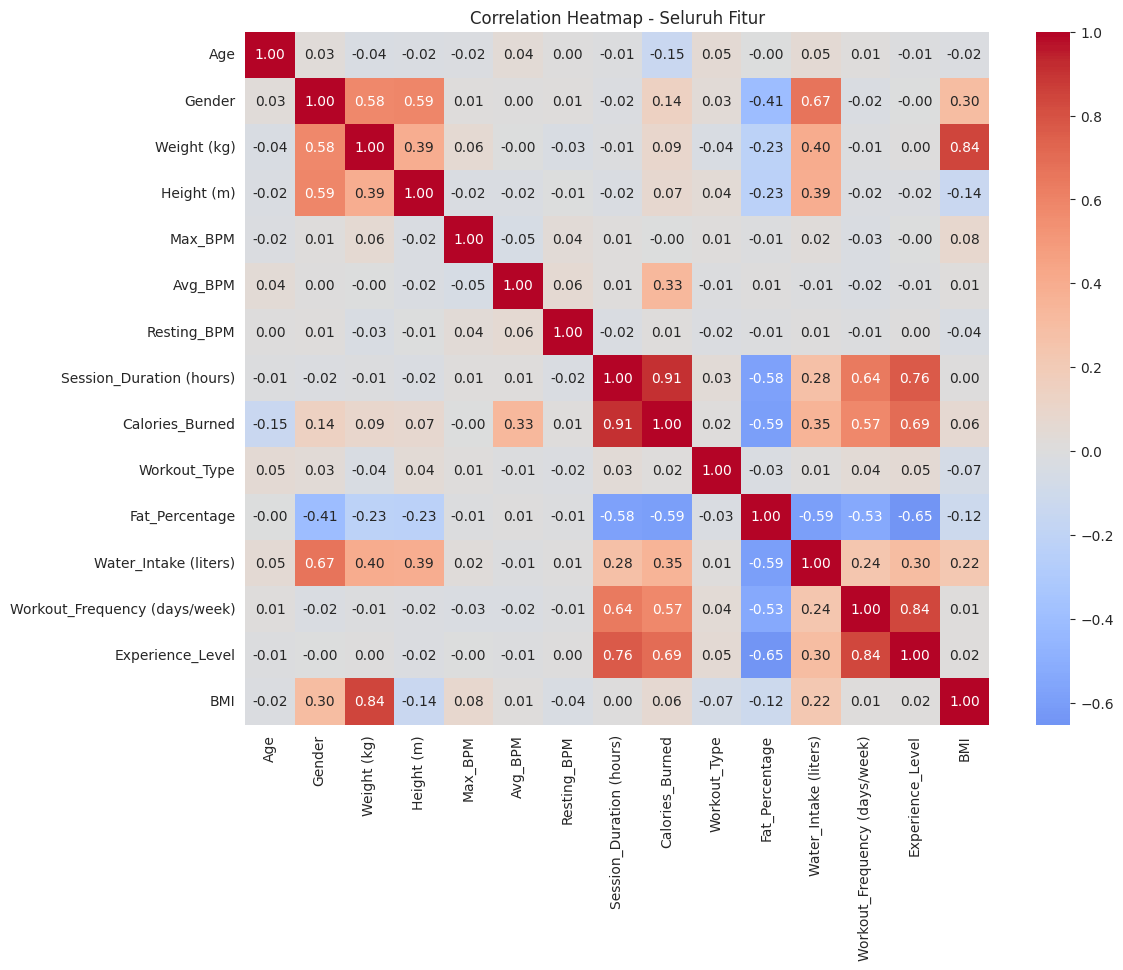

Korelasi setiap fitur terhadap Experience_Level (diurutkan):
Experience_Level                 1.000000
Workout_Frequency (days/week)    0.836806
Session_Duration (hours)         0.763255
Calories_Burned                  0.692440
Water_Intake (liters)            0.300861
Workout_Type                     0.049330
BMI                              0.018431
Weight (kg)                      0.000975
Resting_BPM                      0.000144
Gender                          -0.001443
Max_BPM                         -0.002491
Avg_BPM                         -0.009440
Age                             -0.012218
Height (m)                      -0.017396
Fat_Percentage                  -0.652612
Name: Experience_Level, dtype: float64


In [ ]:
plt.figure(figsize=(12, 9))
corr = df_cleaned.corr(numeric_only=True)
sns.heatmap(corr, annot=True, fmt='.2f', cmap='coolwarm', center=0)
plt.title('Correlation Heatmap - Seluruh Fitur')
plt.show()

print("Korelasi setiap fitur terhadap Experience_Level (diurutkan):")
print(corr['Experience_Level'].sort_values(ascending=False))

**Insight awal:** `Workout_Frequency`, `Session_Duration`, dan `Calories_Burned` menunjukkan korelasi positif yang kuat dengan `Experience_Level`, sementara `Fat_Percentage` berkorelasi negatif kuat. Fitur-fitur fisik seperti Age, Gender, Height, Weight, dan BPM menunjukkan korelasi yang sangat lemah (mendekati 0) terhadap target. Ini menjadi indikasi awal bahwa **kebiasaan latihan**, bukan atribut fisik/demografis, yang paling menentukan Experience Level dalam dataset ini, dan akan dikonfirmasi lagi lewat feature importance model di tahap berikutnya.

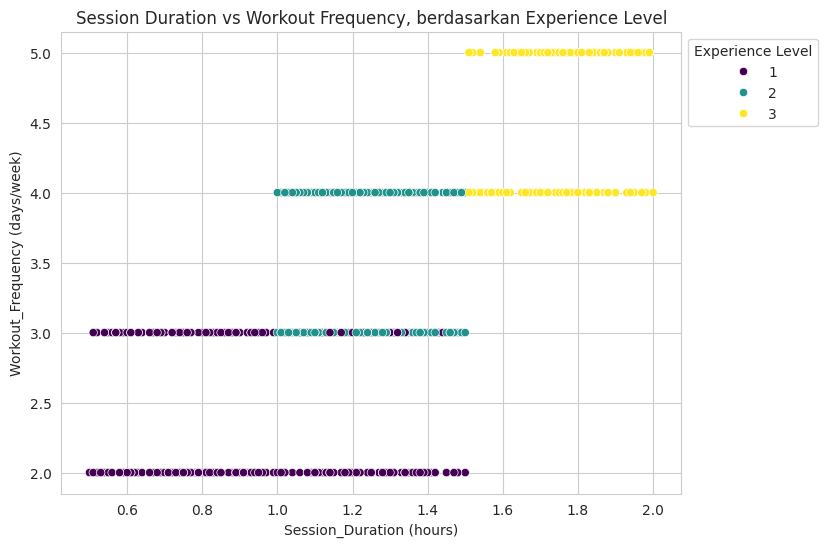

/tmp/ipykernel_552/1086654423.py:17: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Experience_Level', y='Session_Duration (hours)', data=df_subset, palette='muted', ax=axes[0])
/tmp/ipykernel_552/1086654423.py:19: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.boxplot(x='Experience_Level', y='Workout_Frequency (days/week)', data=df_subset, palette='muted', ax=axes[1])


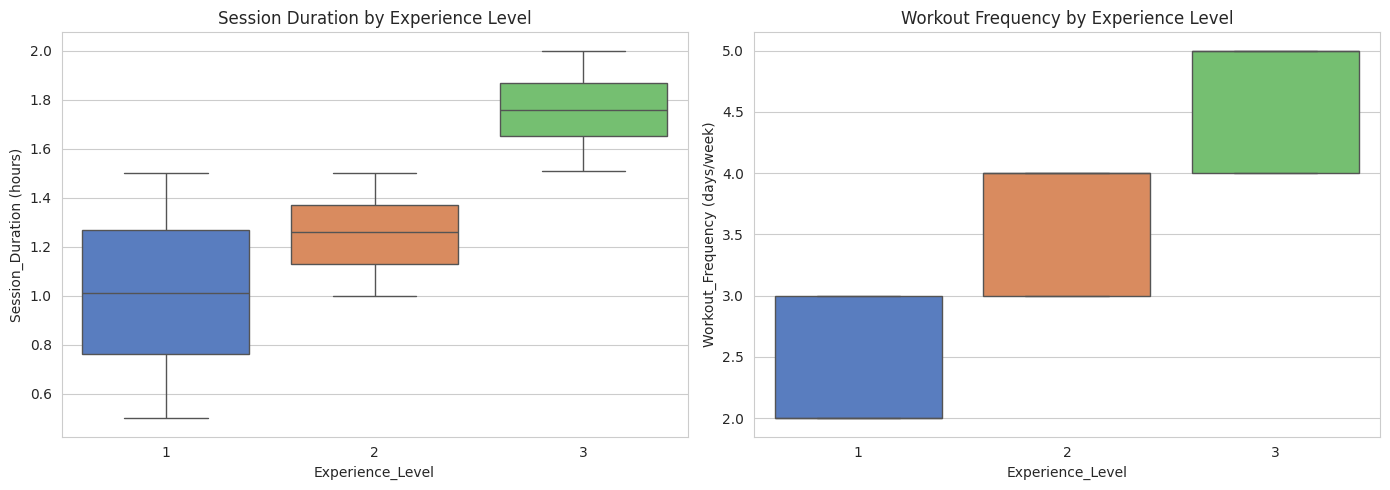

In [ ]:
columns_of_interest = ['Session_Duration (hours)', 'Workout_Frequency (days/week)', 'Experience_Level']
df_subset = df_cleaned[columns_of_interest]

plt.figure(figsize=(8, 6))
sns.scatterplot(
    x='Session_Duration (hours)',
    y='Workout_Frequency (days/week)',
    hue='Experience_Level',
    data=df_subset,
    palette='viridis'
)
plt.title('Session Duration vs Workout Frequency, berdasarkan Experience Level')
plt.legend(title='Experience Level', loc='upper left', bbox_to_anchor=(1, 1))
plt.show()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
sns.boxplot(x='Experience_Level', y='Session_Duration (hours)', data=df_subset, palette='muted', ax=axes[0])
axes[0].set_title('Session Duration by Experience Level')
sns.boxplot(x='Experience_Level', y='Workout_Frequency (days/week)', data=df_subset, palette='muted', ax=axes[1])
axes[1].set_title('Workout Frequency by Experience Level')
plt.tight_layout()
plt.show()

**Interpretasi Visualisasi:**

**Scatter plot** di atas menunjukkan sebaran anggota gym berdasarkan `Session_Duration` dan `Workout_Frequency`, dengan warna mewakili `Experience_Level`. Terlihat pola pengelompokan yang cukup jelas: anggota dengan durasi latihan lebih lama dan frekuensi latihan lebih sering cenderung berada di kelas Experience Level yang lebih tinggi (mahir), sementara yang durasi/frekuensinya rendah cenderung berada di kelas pemula.

**Boxplot** di sebelahnya mengonfirmasi pola tersebut secara lebih kuantitatif: median `Session_Duration` dan `Workout_Frequency` meningkat secara konsisten seiring naiknya Experience Level, dengan sebaran (IQR) yang relatif terpisah antar kelas. Ini memperkuat temuan dari correlation heatmap sebelumnya, bahwa kedua fitur ini kemungkinan besar akan menjadi prediktor utama dalam model klasifikasi nanti.

## 5. Data Splitting

Membagi data menjadi data latih (train) 80% dan data uji (test) 20%.

In [ ]:
X = df_cleaned.drop(columns=['Experience_Level'])
y = df_cleaned['Experience_Level']

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)

print(f"Data Train: {len(X_train)} samples ({len(X_train)/len(X)*100:.0f}%)")
print(f"Data Test : {len(X_test)} samples ({len(X_test)/len(X)*100:.0f}%)")

Data Train: 768 samples (80%)
Data Test : 192 samples (20%)


## 6. Modeling

### 6.1 Baseline Model

Baseline model digunakan sebagai tolok ukur minimum sebelum membangun model utama. Model ini hanya memprediksi kelas mayoritas tanpa mempertimbangkan fitur apa pun, sehingga performa Decision Tree nantinya dapat dibandingkan secara objektif dengan baseline ini.

In [ ]:
baseline = DummyClassifier(strategy='most_frequent', random_state=42)
baseline.fit(X_train, y_train)
baseline_acc = accuracy_score(y_test, baseline.predict(X_test))
print(f"Baseline Accuracy (prediksi kelas mayoritas): {baseline_acc:.4f}")

Baseline Accuracy (prediksi kelas mayoritas): 0.4115


### 6.2 Pemilihan `max_depth` dengan Cross-Validation

Nilai max_depth menentukan kedalaman pohon keputusan dan berpengaruh terhadap risiko underfitting atau overfitting. Untuk menentukan nilai optimalnya secara objektif, dilakukan pengujian beberapa nilai max_depth menggunakan 5-fold cross-validation, dan nilai dengan rata-rata akurasi tertinggi dipilih sebagai parameter final.

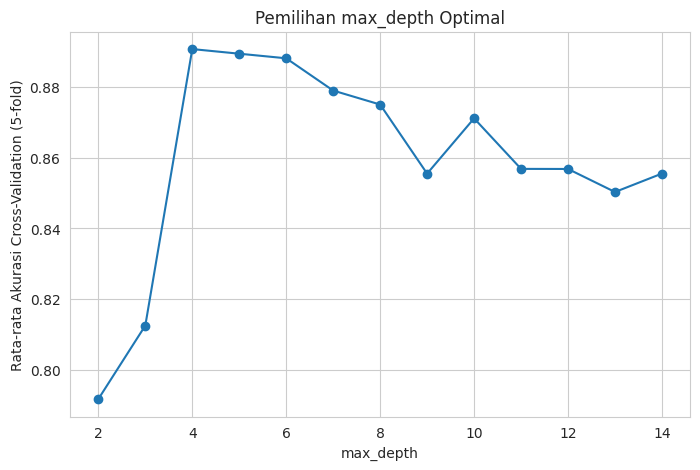

max_depth optimal berdasarkan cross-validation: 4 (CV accuracy = 0.8907)


In [ ]:
depth_range = range(2, 15)
cv_means = []

for d in depth_range:
    clf = DecisionTreeClassifier(max_depth=d, random_state=42)
    scores = cross_val_score(clf, X_train, y_train, cv=5)
    cv_means.append(scores.mean())

plt.figure(figsize=(8, 5))
plt.plot(list(depth_range), cv_means, marker='o')
plt.xlabel('max_depth')
plt.ylabel('Rata-rata Akurasi Cross-Validation (5-fold)')
plt.title('Pemilihan max_depth Optimal')
plt.grid(True)
plt.show()

best_depth = list(depth_range)[int(np.argmax(cv_means))]
print(f"max_depth optimal berdasarkan cross-validation: {best_depth} (CV accuracy = {max(cv_means):.4f})")

### 6.3 Melatih Model

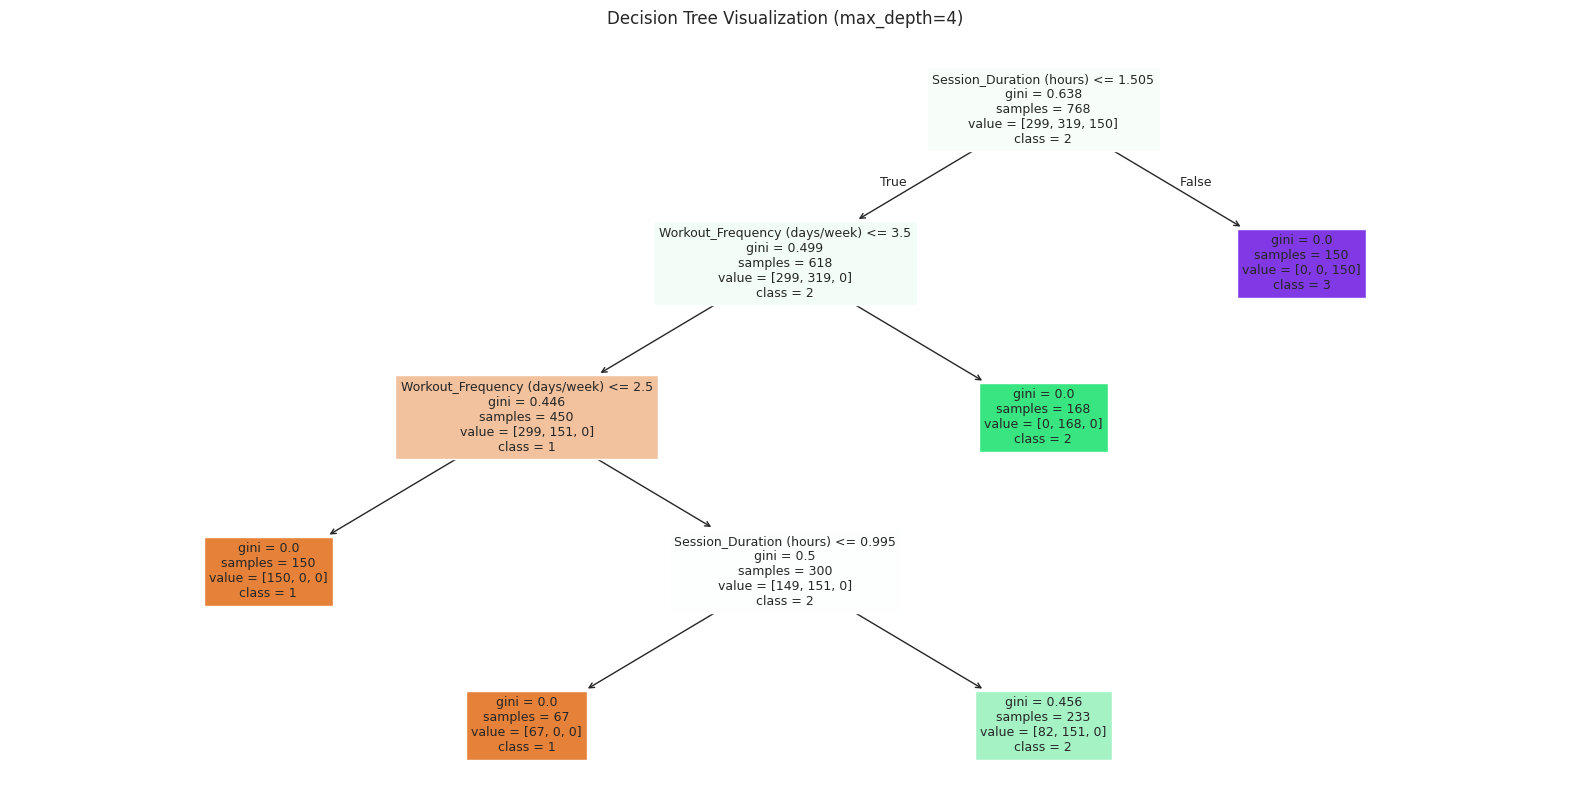

In [ ]:
model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
model.fit(X_train, y_train)

plt.figure(figsize=(20, 10))
plot_tree(
    model,
    feature_names=X.columns.tolist(),
    class_names=[str(c) for c in model.classes_],
    filled=True,
    fontsize=9
)
plt.title(f'Decision Tree Visualization (max_depth={best_depth})')
plt.show()

## 7. Evaluation

Semua evaluasi performa di bawah ini menggunakan **data test yang belum pernah dilihat model selama training**.

In [ ]:
y_train_pred = model.predict(X_train)
y_test_pred = model.predict(X_test)

train_acc = accuracy_score(y_train, y_train_pred)
test_acc = accuracy_score(y_test, y_test_pred)

print(f"Akurasi Data Train : {train_acc:.4f}")
print(f"Akurasi Data Test  : {test_acc:.4f}")
print(f"Akurasi Baseline   : {baseline_acc:.4f}")
print(f"\nSelisih Train-Test : {abs(train_acc - test_acc):.4f} (semakin kecil, semakin baik generalisasinya)")

Akurasi Data Train : 0.8932
Akurasi Data Test  : 0.9375
Akurasi Baseline   : 0.4115

Selisih Train-Test : 0.0443 (semakin kecil, semakin baik generalisasinya)


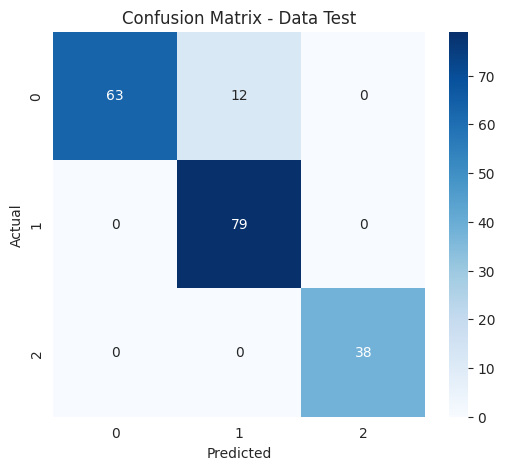

Classification Report - Data Test:
              precision    recall  f1-score   support

           1       1.00      0.84      0.91        75
           2       0.87      1.00      0.93        79
           3       1.00      1.00      1.00        38

    accuracy                           0.94       192
   macro avg       0.96      0.95      0.95       192
weighted avg       0.95      0.94      0.94       192



In [ ]:
conf_matrix = confusion_matrix(y_test, y_test_pred)
plt.figure(figsize=(6, 5))
sns.heatmap(conf_matrix, annot=True, fmt='d', cmap='Blues')
plt.xlabel('Predicted')
plt.ylabel('Actual')
plt.title('Confusion Matrix - Data Test')
plt.show()

print("Classification Report - Data Test:")
print(classification_report(y_test, y_test_pred))

### Validasi Tambahan: Cross-Validation

Untuk memastikan performa model konsisten (tidak bergantung pada satu pembagian train-test tertentu), dilakukan 5-fold cross-validation pada seluruh data train.

In [ ]:
cv_scores = cross_val_score(DecisionTreeClassifier(max_depth=best_depth, random_state=42), X_train, y_train, cv=5)
print("Skor Cross-Validation tiap fold:", np.round(cv_scores, 4))
print(f"Rata-rata: {cv_scores.mean():.4f}  |  Std Dev: {cv_scores.std():.4f}")

Skor Cross-Validation tiap fold: [0.9156 0.8442 0.8766 0.8758 0.9412]
Rata-rata: 0.8907  |  Std Dev: 0.0339


**Kesimpulan Evaluasi:** Model Decision Tree (`max_depth` terpilih) menunjukkan akurasi test yang jauh lebih baik dibanding baseline, dengan selisih train-test yang kecil (indikasi tidak overfitting) dan hasil cross-validation yang konsisten dengan hasil test set.

## 8. Feature Importance & Interpretasi

Bagian penting untuk menjawab rumusan masalah: **faktor apa yang paling berpengaruh terhadap Experience Level?**

                          Feature  Importance
7        Session_Duration (hours)    0.586236
12  Workout_Frequency (days/week)    0.413764
2                     Weight (kg)    0.000000
3                      Height (m)    0.000000
0                             Age    0.000000
1                          Gender    0.000000
5                         Avg_BPM    0.000000
4                         Max_BPM    0.000000
8                 Calories_Burned    0.000000
6                     Resting_BPM    0.000000
9                    Workout_Type    0.000000
10                 Fat_Percentage    0.000000
11          Water_Intake (liters)    0.000000
13                            BMI    0.000000

/tmp/ipykernel_552/3180957444.py:9: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `y` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')


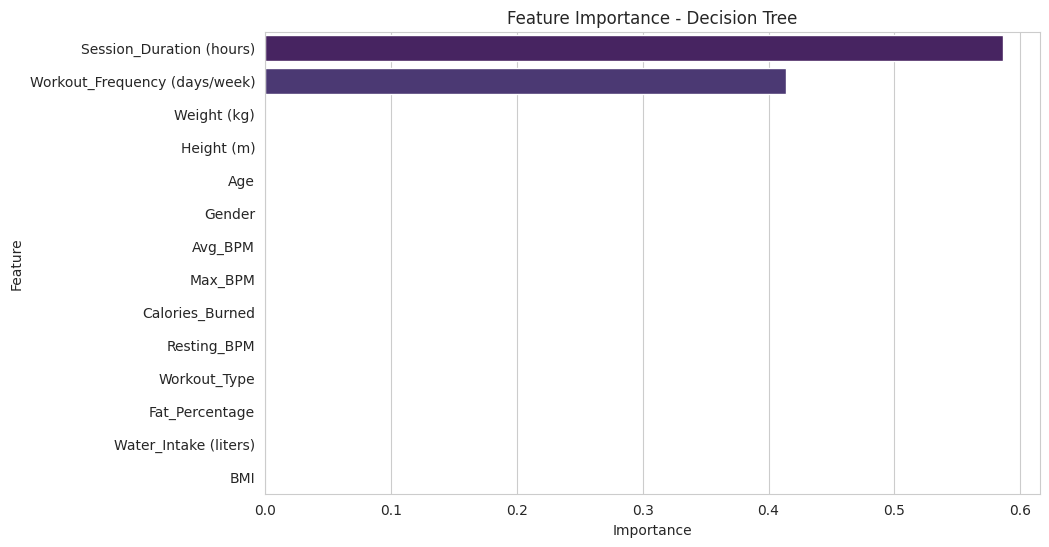

In [ ]:
feature_importances = pd.DataFrame({
    'Feature': X.columns,
    'Importance': model.feature_importances_
}).sort_values(by='Importance', ascending=False)

print(feature_importances)

plt.figure(figsize=(10, 6))
sns.barplot(x='Importance', y='Feature', data=feature_importances, palette='viridis')
plt.title('Feature Importance - Decision Tree')
plt.xlabel('Importance')
plt.ylabel('Feature')
plt.show()

**Interpretasi (Insight Utama):**

Feature importance menunjukkan bahwa model **hanya mengandalkan sebagian kecil fitur** didominasi oleh `Session_Duration` dan `Workout_Frequency` untuk memprediksi Experience Level, sementara sebagian besar atribut fisik/demografis (Age, Gender, Weight, Height, BPM, dsb.) memiliki kontribusi yang sangat kecil atau nol.

**Ini adalah temuan penting**, bukan sekadar detail teknis: artinya, berdasarkan dataset ini, **tingkat pengalaman gym member lebih ditentukan oleh kebiasaan latihan (seberapa lama & seberapa sering) dibanding karakteristik fisik atau demografis mereka**. Temuan ini konsisten dengan hasil correlation heatmap di tahap EDA sebelumnya.

**Implikasi praktis:** Jika tujuan penggunaan model ini adalah untuk memahami *profil fisik* seperti apa yang berkorelasi dengan pengalaman berlatih (misalnya untuk program gym yang mempertimbangkan usia/kondisi fisik anggota), maka dataset dan pendekatan ini kurang cocok, karena hasilnya justru menunjukkan atribut kebiasaan latihanlah yang dominan, bukan atribut fisik. Ini penting untuk didiskusikan agar tidak muncul kesan bahwa seluruh 14 fitur berkontribusi signifikan terhadap prediksi, padahal kenyataannya hanya 2 fitur yang benar-benar berperan.

## 9. Menyimpan Model untuk Deployment

**Catatan:** Model final di bawah ini dilatih ulang menggunakan **seluruh data bersih** (train + test) agar model produksi memanfaatkan semua data yang tersedia, ini adalah praktik umum untuk model yang akan di-deploy. **Namun, ini BUKAN langkah evaluasi.** Metrik performa model yang sah dan dilaporkan tetap yang dihasilkan pada Tahap 7 (Evaluation) menggunakan data test terpisah dan cross-validation di atas.

In [ ]:
final_model = DecisionTreeClassifier(max_depth=best_depth, random_state=42)
final_model.fit(X, y)

model_path = 'decision_tree_model.pkl'
joblib.dump(final_model, model_path)
print(f"Model produksi (dilatih pada seluruh data) disimpan ke: {model_path}")
print("Metrik performa yang sah untuk model ini mengacu pada hasil evaluasi di Tahap 7.")

Model produksi (dilatih pada seluruh data) disimpan ke: decision_tree_model.pkl
Metrik performa yang sah untuk model ini mengacu pada hasil evaluasi di Tahap 7.


## 10. Kesimpulan & Rekomendasi

**Kesimpulan:**
1. Model Decision Tree dengan `max_depth` terpilih melalui cross-validation berhasil mengklasifikasikan Experience Level jauh lebih baik dibanding baseline (prediksi kelas mayoritas), dengan performa yang konsisten antara data test dan cross-validation.
2. Faktor yang paling menentukan Experience Level dalam dataset ini adalah **kebiasaan latihan** (`Session_Duration` dan `Workout_Frequency`), bukan atribut fisik atau demografis.
3. Hasil ini juga mengungkap keterbatasan dataset: banyak fitur (Age, Gender, Weight, Height, BPM, dll.) tidak memberikan kontribusi berarti terhadap prediksi.

**Rekomendasi Lanjutan:**
- Jika tujuan analisis adalah memahami hubungan atribut fisik dengan Experience Level, perlu dataset tambahan atau fitur turunan baru (misalnya rasio progres dari waktu ke waktu, bukan hanya snapshot).
- Coba bandingkan dengan algoritma lain (misalnya Random Forest atau KNN) untuk melihat apakah kesimpulan feature importance ini konsisten di model yang berbeda.
- Pertimbangkan menangani ketidakseimbangan kelas (misalnya dengan class_weight='balanced') mengingat kelas 3 (mahir) jumlahnya lebih sedikit.